
## 1. Цель исследования

**Задача:**  
Оценить влияние индивидуальных и страновых факторов на зависимую переменную (Y),  
учитывая иерархическую структуру данных (индивиды вложены в страны).

Определяем:

- **Y** – зависимая переменная  
- **X_individual** – предикторы индивидуального уровня  
- **X_country** – предикторы странового уровня

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [2]:
df = pd.read_csv('/content/drive/MyDrive/ESS1e06_7.csv', low_memory=False)
df

,name,essround,edition,proddate,idno,cntry,dweight,pspwght,pweight,anweight,...,inwdd,inwmm,inwyr,inwshh,inwsmm,inwemm,inwehh,inwtm,spltadm,supqadm
0,ESS1e06_7,1,6.7,23.11.2023,1,AT,0.9452,0.940933,0.271487,0.255451,...,23.0,3.0,2003,13,30,20,14,50.0,10.0,1.0
1,ESS1e06_7,1,6.7,23.11.2023,2,AT,0.4726,0.470466,0.271487,0.127726,...,29.0,3.0,2003,14,0,0,15,60.0,9.0,1.0
2,ESS1e06_7,1,6.7,23.11.2023,3,AT,0.9452,1.392155,0.271487,0.377953,...,31.0,3.0,2003,18,0,10,19,70.0,10.0,1.0
3,ESS1e06_7,1,6.7,23.11.2023,4,AT,0.9452,1.382163,0.271487,0.375240,...,3.0,4.0,2003,11,55,0,13,65.0,9.0,1.0
4,ESS1e06_7,1,6.7,23.11.2023,6,AT,1.8905,1.437766,0.271487,0.390336,...,1.0,4.0,2003,12,55,55,13,60.0,9.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42354,ESS1e06_7,1,6.7,23.11.2023,1810,SI,1.0000,1.249730,0.109537,0.136892,...,20.0,11.0,2002,17,15,45,18,90.0,12.0,1.0
42355,ESS1e06_7,1,6.7,23.11.2023,1811,SI,1.0000,1.049310,0.109537,0.114938,...,23.0,11.0,2002,16,30,10,18,100.0,13.0,1.0
42356,ESS1e06_7,1,6.7,23.11.2023,1812,SI,1.0000,1.103449,0.109537,0.120869,...,21.0,11.0,2002,17,0,20,18,80.0,13.0,1.0
42357,ESS1e06_7,1,6.7,23.11.2023,1813,SI,1.0000,1.186905,0.109537,0.130010,...,18.0,11.0,2002,17,5,10,18,65.0,15.0,1.0


Вычислим размер получившегося датасета.

In [3]:
print(f'Количество строк: {df.shape[0]} \nКоличество столбцов: {df.shape[1]}')

Количество строк: 42359 
Количество столбцов: 567


Ряд переменных являются техническими и не будут иметь какую-либо ценность при построении модели:
* name - Название файла данных (ESS1e06_7)
* edition - Версия набора данных
* preddate - Дата выпуска файла
* idno - Уникальный номер респондента
* psu - Primary Sampling Unit (первичная единица выборки)
* stratum - Стратификационная переменная
* prob - Вероятность включения в выборку
* inwdd, inwmm, inwyr - Дата интервью
* inwshh, inwsmm, inwemm, inwehh, inwtm - Время начала и конца интервью.

In [4]:
technical_vars = [
    "name", "edition", "proddate", "idno",
    "psu", "stratum", "prob",
    "inwdd", "inwmm", "inwyr",
    "inwshh", "inwsmm", "inwemm", "inwehh", "inwtm"]

df = df.drop(columns=[x for x in technical_vars if x in df.columns])

Признаки из датасета закодированы таким образом, что значения "Отказ", "Не знаю", "Нет ответа" как числа в формате "ХХХХ", "ХХХ", "ХХ"б "Х", поэтому предобработаем датасет в четыре шага:
1. Переведем сначала признаки со значениями ХХХХ.
2. Далее ХХХ.
3. После ХХ.
4. Последним шагом переведем признаки Х.

In [5]:
codes_1 = {9999, 8888, 7777}
codes_2 = {999, 888, 777, 666}
codes_3 = {99, 88, 77, 66}
codes_4 = {9, 8, 7}
changed_step1 = set()
changed_step2 = set()
changed_step3 = set()
for col in df.columns:
    s = df[col]

    # шаг 1
    if s.isin(codes_1).any():
        df.loc[s.isin(codes_1), col] = np.nan
        changed_step1.add(col)
        continue

    # шаг 2
    if s.isin(codes_2).any():
        df.loc[s.isin(codes_2), col] = np.nan
        changed_step2.add(col)
        continue

    # шаг 3
    if s.isin(codes_3).any():
        df.loc[s.isin(codes_3), col] = np.nan
        changed_step3.add(col)
        continue

    # шаг 4
    if s.isin(codes_4).any():
        df.loc[s.isin(codes_4), col] = np.nan

In [6]:
df

,essround,cntry,dweight,pspwght,pweight,anweight,tvtot,tvpol,rdtot,rdpol,...,ipstrgv,ipadvnt,ipbhprp,iprspot,iplylfr,impenv,imptrad,impfun,spltadm,supqadm
0,1,AT,0.9452,0.940933,0.271487,0.255451,1.0,1.0,1.0,1.0,...,2.0,3.0,4.0,4.0,2.0,2.0,1.0,1.0,10.0,1.0
1,1,AT,0.4726,0.470466,0.271487,0.127726,3.0,2.0,4.0,1.0,...,3.0,1.0,4.0,4.0,3.0,1.0,6.0,3.0,9.0,1.0
2,1,AT,0.9452,1.392155,0.271487,0.377953,7.0,3.0,0.0,NaN,...,2.0,4.0,2.0,3.0,2.0,2.0,2.0,5.0,10.0,1.0
3,1,AT,0.9452,1.382163,0.271487,0.375240,1.0,1.0,1.0,1.0,...,3.0,6.0,2.0,4.0,2.0,1.0,5.0,5.0,9.0,1.0
4,1,AT,1.8905,1.437766,0.271487,0.390336,0.0,NaN,1.0,1.0,...,4.0,4.0,6.0,5.0,1.0,1.0,3.0,2.0,9.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42354,1,SI,1.0000,1.249730,0.109537,0.136892,1.0,1.0,0.0,NaN,...,2.0,5.0,3.0,3.0,4.0,2.0,5.0,4.0,12.0,1.0
42355,1,SI,1.0000,1.049310,0.109537,0.114938,3.0,3.0,2.0,2.0,...,2.0,6.0,3.0,5.0,5.0,2.0,2.0,5.0,13.0,1.0
42356,1,SI,1.0000,1.103449,0.109537,0.120869,7.0,2.0,0.0,NaN,...,2.0,3.0,3.0,5.0,3.0,2.0,5.0,3.0,13.0,1.0
42357,1,SI,1.0000,1.186905,0.109537,0.130010,2.0,2.0,2.0,2.0,...,1.0,6.0,1.0,3.0,2.0,1.0,1.0,2.0,15.0,1.0


Кодировка прошла успешна, например третье значение столбца "rdpol" изменилось на NaN.

545 признаков для анализа будут не нужны, поскольку это слишком много, для бóльшей проработки необходимо их сократить, оставив только несколько "Блоков признаков".
1. Оставляем базовые человеческие потребности, которые являются основой "Модели Шварца", на базе которой проводятся все современные социальные опросы. К данным признакам относятся: отношение к новизне (impdiff, ipadvnt, ipcrtiv, impfree), соблюдение традиций и общественного порядка (imptrad, ipbhprp, impsafe, ipstrgv), определяемый статус (imprich, ipsuces, ipshabt) и удовольствие (impfun).
2. Второй группой будут признаки отражающие социальное доверие (ppltrst, pplfair, pplhlp).
3. И наконец, последняя группа - количество потребляемой информации через ТВ и медиа (tvtot, rdtot, nwsptot, netuse).
Создадим итоговый датафрейм для дальнейшего анализа.

In [7]:
value_vars = [
    "impdiff","impfree","ipadvnt","ipcrtiv",
    "imptrad","ipbhprp","impsafe","ipstrgv",
    "ipeqopt","iphlppl","ipudrst","iplylfr",
    "imprich","ipsuces","ipshabt", "impfun"]

trust_vars = ["ppltrst", "pplfair", "pplhlp"]

tv_media_vars = ['tvtot', 'rdtot', 'nwsptot', 'netuse']
df_model = df[["cntry"] + value_vars + trust_vars + tv_media_vars]
df_model

,cntry,impdiff,impfree,ipadvnt,ipcrtiv,imptrad,ipbhprp,impsafe,ipstrgv,ipeqopt,...,ipsuces,ipshabt,impfun,ppltrst,pplfair,pplhlp,tvtot,rdtot,nwsptot,netuse
0,AT,3.0,1.0,3.0,2.0,1.0,4.0,2.0,2.0,1.0,...,3.0,3.0,1.0,7.0,7.0,7.0,1.0,1.0,1.0,5.0
1,AT,1.0,1.0,1.0,1.0,6.0,4.0,4.0,3.0,1.0,...,1.0,2.0,3.0,6.0,3.0,0.0,3.0,4.0,2.0,6.0
2,AT,3.0,3.0,4.0,2.0,2.0,2.0,3.0,2.0,2.0,...,2.0,2.0,5.0,0.0,3.0,8.0,7.0,0.0,0.0,0.0
3,AT,3.0,3.0,6.0,1.0,5.0,2.0,2.0,3.0,2.0,...,4.0,4.0,5.0,8.0,5.0,7.0,1.0,1.0,2.0,4.0
4,AT,4.0,1.0,4.0,3.0,3.0,6.0,4.0,4.0,1.0,...,4.0,3.0,2.0,8.0,8.0,6.0,0.0,1.0,0.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42354,SI,4.0,2.0,5.0,2.0,5.0,3.0,2.0,2.0,3.0,...,5.0,3.0,4.0,4.0,4.0,3.0,1.0,0.0,0.0,1.0
42355,SI,4.0,2.0,6.0,2.0,2.0,3.0,2.0,2.0,2.0,...,4.0,2.0,5.0,5.0,7.0,5.0,3.0,2.0,1.0,1.0
42356,SI,3.0,2.0,3.0,3.0,5.0,3.0,3.0,2.0,3.0,...,3.0,2.0,3.0,0.0,5.0,3.0,7.0,0.0,0.0,1.0
42357,SI,3.0,2.0,6.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.0,1.0,2.0,8.0,5.0,5.0,2.0,2.0,1.0,1.0


Датафрейм предобработан, можно начинать EDA.
1. Обработка и анализ пропусков.
Для корректного анализа необходимо выделить признаки отдельно.

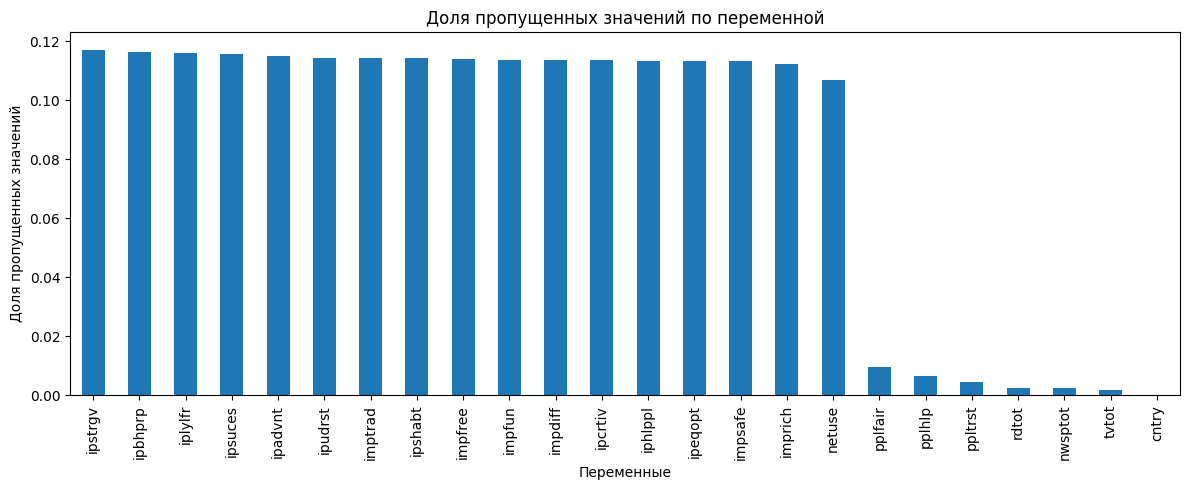

In [8]:
missing_rate = df_model.isna().mean().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
missing_rate.plot(kind="bar")
plt.title("Доля пропущенных значений по переменной")
plt.ylabel("Доля пропущенных значений")
plt.xlabel("Переменные")
plt.tight_layout()
plt.show()


Доля пропущенных значений не превышает 12% - достаточно приличные результаты.

2. Общая описательная статистика.

In [9]:
df_model.describe()

,impdiff,impfree,ipadvnt,ipcrtiv,imptrad,ipbhprp,impsafe,ipstrgv,ipeqopt,iphlppl,...,ipsuces,ipshabt,impfun,ppltrst,pplfair,pplhlp,tvtot,rdtot,nwsptot,netuse
count,37546.000000,37526.000000,37493.000000,37548.000000,37519.000000,37438.000000,37566.000000,37398.000000,37564.000000,37557.000000,...,37455.000000,37525.000000,37545.000000,42166.000000,41950.000000,42088.000000,42280.000000,42250.000000,42252.000000,37828.000000
mean,2.964550,2.143980,3.940442,2.515527,2.738026,2.694882,2.317841,2.385261,2.064716,2.298506,...,3.175330,3.217109,2.985724,5.010316,5.591585,4.765016,4.241958,3.147976,1.458061,2.559823
std,1.371201,1.074656,1.452344,1.217476,1.371522,1.269890,1.212221,1.228164,1.042219,1.007830,...,1.353138,1.402655,1.376246,2.489101,2.404691,2.402547,2.040884,2.622198,1.313264,2.837887
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,3.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,2.000000,...,2.000000,2.000000,2.000000,3.000000,4.000000,3.000000,3.000000,1.000000,1.000000,0.000000
50%,3.000000,2.000000,4.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,3.000000,3.000000,3.000000,5.000000,6.000000,5.000000,4.000000,2.000000,1.000000,1.000000
75%,4.000000,3.000000,5.000000,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,4.000000,4.000000,4.000000,7.000000,7.000000,7.000000,6.000000,6.000000,2.000000,6.000000
max,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,10.000000,10.000000,10.000000,7.000000,7.000000,7.000000,7.000000


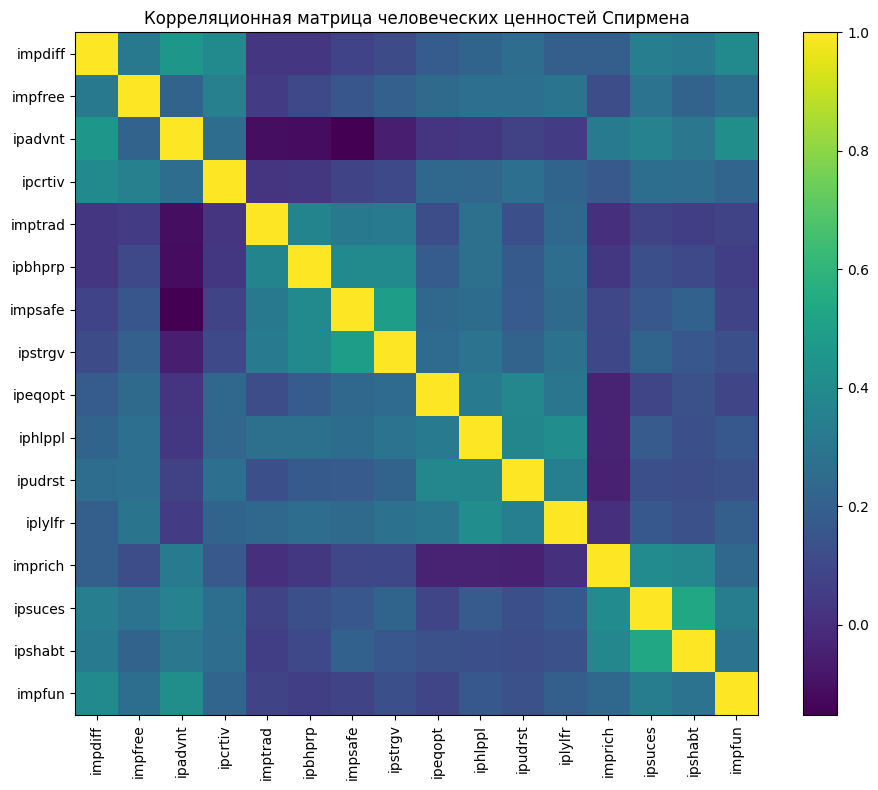

In [10]:
corr = df_model[value_vars].corr(method="spearman")

plt.figure(figsize=(10, 8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(value_vars)), value_vars, rotation=90)
plt.yticks(range(len(value_vars)), value_vars)
plt.title("Корреляционная матрица человеческих ценностей Спирмена")
plt.tight_layout()
plt.show()


Как и ожидалось матрица корреляции показывает четкую зависимость между признаками одного блока.
Использование всех индикаторов напрямую в регрессии приведёт к мультиколлинеарности.

In [11]:
df_model["openness"] = df_model[
    ["impdiff", "impfree", "ipadvnt", "ipcrtiv"]
].mean(axis=1)

df_model["conservation"] = df_model[
    ["imptrad", "ipbhprp", "impsafe", "ipstrgv"]
].mean(axis=1)

df_model["self_transcendence"] = df_model[
    ["ipeqopt", "iphlppl", "ipudrst", "iplylfr"]
].mean(axis=1)

df_model["self_enhancement"] = df_model[
    ["imprich", "ipsuces", "ipshabt"]
].mean(axis=1)
indices = [
    "openness",
    "conservation",
    "self_transcendence",
    "self_enhancement"
]

/tmp/ipykernel_576/1297388615.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["openness"] = df_model[
/tmp/ipykernel_576/1297388615.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["conservation"] = df_model[
/tmp/ipykernel_576/1297388615.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

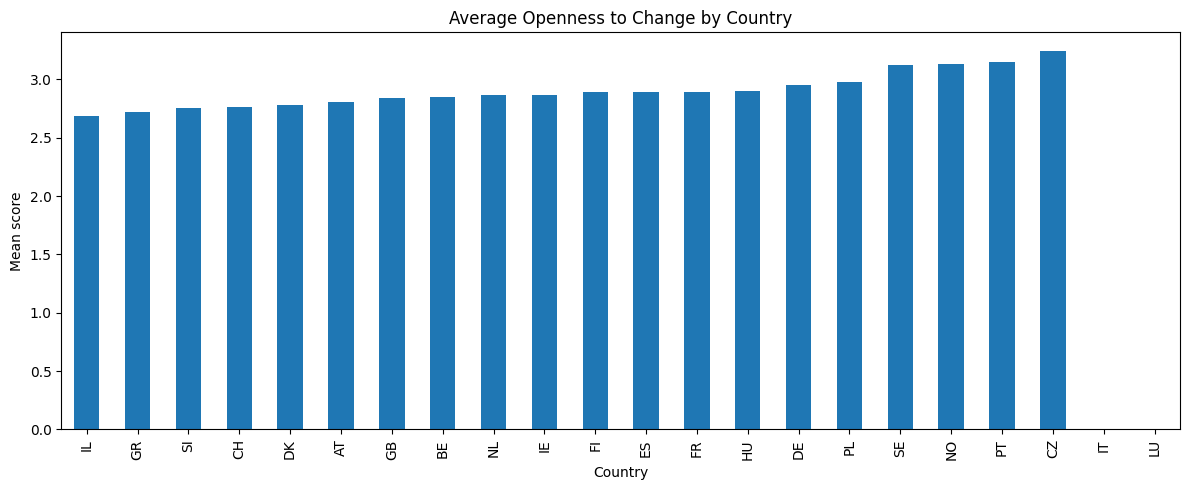

In [12]:
country_means = df_model.groupby("cntry")[indices].mean()

plt.figure(figsize=(12, 5))
country_means["openness"].sort_values().plot(kind="bar")
plt.title("Average Openness to Change by Country")
plt.xlabel("Country")
plt.ylabel("Mean score")
plt.tight_layout()
plt.show()

Несмотря на то что различия в абсолютных значениях не экстремальны, они устойчивы, систематичны и наблюдаются на уровне средних значений.
В ряде стран наблюдаются более высокие средние значения, отражающие ориентацию на автономию, новизну и индивидуальный выбор, тогда как в других странах данные установки выражены слабее. Полученные различия указывают на значимую роль странового контекста в формировании ценностных ориентаций и обосновывают использование многоуровневых моделей в дальнейшем анализе.

Обучение базовой модели и проверка основной research-идеи

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)

from IPython.display import display

Будем использовать как целевую переменную "Доверие к людям".

In [14]:
df_model = df_model.copy()
df_model['target'] = (df_model['ppltrst'] >= 5).astype(int)

In [15]:
df_model.columns

Index(['cntry', 'impdiff', 'impfree', 'ipadvnt', 'ipcrtiv', 'imptrad',
       'ipbhprp', 'impsafe', 'ipstrgv', 'ipeqopt', 'iphlppl', 'ipudrst',
       'iplylfr', 'imprich', 'ipsuces', 'ipshabt', 'impfun', 'ppltrst',
       'pplfair', 'pplhlp', 'tvtot', 'rdtot', 'nwsptot', 'netuse', 'openness',
       'conservation', 'self_transcendence', 'self_enhancement', 'target'],
      dtype='object')

Формируем признаки. Как базовые, так и полные, а также добавим две "фичи"

In [16]:
features_base = ["tvtot", "rdtot", "nwsptot", "netuse"]
features_full = [
    "tvtot", "rdtot", "nwsptot", "netuse",
    "openness", "conservation",
    "self_transcendence", "self_enhancement"
]
df_model["media_index"] = df_model[["tvtot", "rdtot", "nwsptot", "netuse"]].mean(axis=1)
df_model["openness_minus_conservation"] = df_model["openness"] - df_model["conservation"]
features_fe = [
    "media_index",
    "openness",
    "conservation",
    "self_transcendence",
    "self_enhancement",
    "openness_minus_conservation"
]

Создаем функцию, чтобы не прописывать под каждую модель отдельно.

In [25]:
def run_model(features):
    X = df_model[features]
    y = df_model["target"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), features)
    ])

    model = Pipeline([
        ("prep", preprocessor),
        ("model", LogisticRegression(max_iter=2000))
    ])

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    results = {
        "train_f1": f1_score(y_train, y_train_pred),
        "test_f1": f1_score(y_test, y_test_pred),
        "test_roc_auc": roc_auc_score(y_test, y_test_proba),
        "overfit": f1_score(y_train, y_train_pred) - f1_score(y_test, y_test_pred)
    }

    return results, model, X_test, y_test

Запуск моделей

In [32]:
base_metrics, base_model, base_X_test, base_y_test = run_model(features_base)
full_metrics, full_model, full_X_test, full_y_test = run_model(features_full)
fe_metrics, fe_model, fe_X_test, fe_y_test = run_model(features_fe)

results = {
    "BASE (media only)": base_metrics,
    "FULL (media + values)": full_metrics,
    "FE (engineered features)": fe_metrics
}

results_df = pd.DataFrame(results).T
results_df

,train_f1,test_f1,test_roc_auc,overfit
BASE (media only),0.765536,0.768001,0.625354,-0.002465
FULL (media + values),0.759832,0.759920,0.641186,-0.000088
FE (engineered features),0.763850,0.761478,0.611062,0.002372


В рамках данного этапа в качестве целевой переменной был выбран уровень социального доверия (ppltrst), преобразованный в бинарную переменную.
На первом этапе была обучена базовая модель с использованием только показателей медиапотребления. Она показала значение F1-score ≈ 0.768 и ROC-AUC ≈ 0.625.
Добавление ценностных переменных (openness, conservation и др.) не привело к улучшению качества по основной метрике (F1-score ≈ 0.760), однако увеличило значение ROC-AUC до ≈ 0.641. Это свидетельствует о том, что ценностные характеристики содержат дополнительную информацию и улучшают способность модели различать классы, но не оказывают существенного влияния на итоговую классификацию при выбранном пороге.
Применение feature engineering (агрегированный индекс медиапотребления и разность openness и conservation) не привело к улучшению качества модели и даже немного ухудшило ROC-AUC, что может свидетельствовать о том, что исходные признаки уже содержали достаточную информацию, а новые признаки не добавили значимого сигнала.
Разница между качеством на обучающей и тестовой выборках во всех моделях минимальна, что указывает на отсутствие переобучения и хорошую обобщающую способность моделей.
Таким образом, можно сделать вывод, что медиапотребление играет основную роль в объяснении уровня социального доверия, тогда как ценностные ориентации оказывают дополнительное, но ограниченное влияние.

Полученные результаты показывают, что модель уже обладает хорошей обобщающей способностью, однако есть потенциал для её дальнейшего улучшения. Одним из способов повышения качества является оптимизация порога классификации, так как стандартное значение 0.5 не всегда максимизирует F1-score.

In [33]:
def find_best_threshold(model, X_test, y_test):
    y_proba = model.predict_proba(X_test)[:, 1]

    thresholds = np.linspace(0.1, 0.9, 50)
    best_f1 = 0
    best_thresh = 0.5

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        f1 = f1_score(y_test, y_pred)

        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t

    return best_thresh, best_f1

In [34]:
best_t, best_f1 = find_best_threshold(base_model, base_X_test, base_y_test)

print("Лучший порог:", best_t)
print("Лучший F1:", best_f1)

Лучший порог: 0.1
Лучший F1: 0.7708378672470076


Дополнительно была выполнена оптимизация порога классификации. Было показано, что стандартное значение 0.5 не является оптимальным для метрики F1-score. Подбор порога позволил увеличить значение F1-score до 0.771 (при пороге 0.1), что свидетельствует о возможности улучшения качества модели без изменения её структуры.
Таким образом, можно сделать вывод, что медиапотребление является основным фактором, связанным с уровнем социального доверия, тогда как ценностные ориентации играют дополнительную, но ограниченную роль.